In [1]:
from pathlib import Path

FIGS_ROOT = Path("figs")
CONFIG_IDS = ["config_018", "config_013", "config_012", "config_014", "config_015", "config_017"]
PRIORS = ["uniform", "normal", "exponential"]
LOAD_RAW = True
RAW_CONFIG_IDS = ["config_018", "config_017"]


# Dimensionality Analysis

This notebook compares the clean 1D-6D `toy_example_nD_tidy.py` sweep using the summary artifacts already written to `figs/`.

It is organized in two layers:
- A fast summary layer driven by `config.json`, `posterior_errors/analysis_bundle.json`, `verifications/model_quality_summary.json`, and `verifications/reweighting_quality_summary.json`.
- An optional compact-store deep dive driven by `ratio_map.npy` and the ratio HPD interval arrays referenced by each `analysis_bundle.json`.

Notes:
- The default sweep is `config_018, 013, 012, 014, 015, 017`, which resolve to dimensions `1, 2, 3, 4, 5, 6`.
- `config_011` is treated as a legacy run and is intentionally ignored here.
- The raw deep-dive loader automatically samples very large compact-store arrays so higher-dimensional examples remain usable.

In [2]:
import warnings

import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D

from src.dimensionality_analysis import (
    RAW_MAX_POINTS_PER_CONFIG,
    load_dimensionality_summary,
    load_raw_compact_store,
)

warnings.simplefilter("default")
pd.options.display.max_columns = 50
pd.options.display.float_format = "{:.3f}".format

PRIOR_COLORS = {
    "uniform": "#1f77b4",
    "normal": "#d17a22",
    "exponential": "#2a9d4b",
}
PRIOR_MARKERS = {
    "uniform": "o",
    "normal": "s",
    "exponential": "^",
}
PRIOR_LABELS = {prior: prior.title() for prior in PRIOR_COLORS}


def normalized_config_ids(config_ids):
    return [config_id if str(config_id).startswith("config_") else f"config_{config_id}" for config_id in config_ids]


def build_compact_metric_table(runs_df):
    columns = [
        "config_id",
        "dimension",
        "prior",
        "pooled_rmse_log_r10",
        "median_rmse_log_r10",
        "worst_rmse_log_r10",
        "median_ess_fraction",
        "median_swd",
        "coverage_68",
        "coverage_95",
        "mean_interval_width_68",
        "mean_interval_width_95",
    ]
    return runs_df[columns].sort_values(["dimension", "prior"]).reset_index(drop=True)


def plot_prior_lines(ax, data, metric, title, ylabel, *, logy=False):
    dimensions = sorted(data["dimension"].unique()) if not data.empty else []
    for prior in PRIORS:
        subset = data.loc[data["prior"] == prior].sort_values("dimension")
        if subset.empty:
            continue
        ax.plot(
            subset["dimension"],
            subset[metric],
            marker=PRIOR_MARKERS.get(prior, "o"),
            linewidth=2,
            color=PRIOR_COLORS.get(prior),
            label=PRIOR_LABELS.get(prior, prior),
        )
    ax.set_title(title)
    ax.set_xlabel("Dimension")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    if dimensions:
        ax.set_xticks(dimensions)
    if logy:
        ax.set_yscale("log")


def build_correlation_summary(runs_df, pairs_df):
    rows = []
    if pairs_df.empty:
        return pd.DataFrame()

    for (config_id, dimension, prior), subset in pairs_df.groupby(["config_id", "dimension", "prior"]):
        run_row = runs_df.loc[
            (runs_df["config_id"] == config_id)
            & (runs_df["dimension"] == dimension)
            & (runs_df["prior"] == prior)
        ].iloc[0]
        rows.append(
            {
                "config_id": config_id,
                "dimension": dimension,
                "prior": prior,
                "stored_spearman_rmse_vs_distance": run_row["spearman_rmse_vs_distance"],
                "empirical_spearman_rmse_vs_distance": subset["distance"].corr(
                    subset["rmse_log_r10"], method="spearman"
                ),
                "empirical_pearson_rmse_vs_distance": subset["distance"].corr(
                    subset["rmse_log_r10"], method="pearson"
                ),
                "stored_spearman_swd_vs_distance": run_row["spearman_swd_vs_distance"],
                "empirical_spearman_swd_vs_distance": subset["distance"].corr(
                    subset["swd"], method="spearman"
                ),
                "empirical_pearson_swd_vs_distance": subset["distance"].corr(
                    subset["swd"], method="pearson"
                ),
                "empirical_spearman_ess_fraction_vs_distance": subset["distance"].corr(
                    subset["ess_fraction"], method="spearman"
                ),
            }
        )
    return pd.DataFrame(rows).sort_values(["dimension", "prior"]).reset_index(drop=True)


def build_scaling_observation_markdown(runs_df):
    if runs_df.empty:
        return Markdown("No runs were loaded.")

    mean_by_dim = runs_df.groupby("dimension").agg(
        mean_pooled_rmse=("pooled_rmse_log_r10", "mean"),
        mean_coverage_68=("coverage_68", "mean"),
        mean_coverage_95=("coverage_95", "mean"),
        mean_ess_fraction=("median_ess_fraction", "mean"),
        mean_swd=("median_swd", "mean"),
    ).sort_index()
    growth = mean_by_dim["mean_pooled_rmse"].pct_change()

    lines = ["### Scaling interpretation"]
    if growth.notna().any():
        sharpest_dim = int(growth.fillna(-np.inf).idxmax())
        sharpest_position = list(mean_by_dim.index).index(sharpest_dim)
        previous_dim = int(mean_by_dim.index[sharpest_position - 1])
        lines.append(
            f"- The sharpest average pooled-RMSE jump occurs between **{previous_dim}D** and **{sharpest_dim}D**, "
            f"where the mean pooled RMSE rises from **{mean_by_dim.loc[previous_dim, 'mean_pooled_rmse']:.2f}** "
            f"to **{mean_by_dim.loc[sharpest_dim, 'mean_pooled_rmse']:.2f}**."
        )

    coverage_collapse = mean_by_dim.loc[mean_by_dim["mean_coverage_68"] < 0.50]
    if not coverage_collapse.empty:
        collapse_dim = int(coverage_collapse.index[0])
        lines.append(
            f"- Mean 68% HPD coverage drops below **0.50** at **{collapse_dim}D**, "
            f"which is a strong sign that uncertainty is becoming under-dispersed in the higher-dimensional runs."
        )

    ess_collapse = mean_by_dim.loc[mean_by_dim["mean_ess_fraction"] < 0.01]
    if not ess_collapse.empty:
        ess_dim = int(ess_collapse.index[0])
        lines.append(
            f"- Median effective-sample-size fraction falls below **1%** by **{ess_dim}D**, "
            f"which matches the worsening reweighting difficulty seen in the SWD plots."
        )

    final_dim = int(mean_by_dim.index.max())
    lines.append(
        f"- By **{final_dim}D**, the sweep combines larger ratio error, lower ESS, and much weaker empirical coverage, "
        "so the failure mode is not just a single metric moving in isolation."
    )
    return Markdown("\n".join(lines))


def plot_curve_family(curves_df, metric, ylabel, title_prefix, *, figsize=(15, 4)):
    dimensions = sorted(curves_df["dimension"].unique()) if not curves_df.empty else []
    dimension_colors = {
        dim: plt.cm.viridis(index)
        for dim, index in zip(
            dimensions,
            np.linspace(0.1, 0.9, num=max(len(dimensions), 1)),
        )
    }
    fig, axes = plt.subplots(1, len(PRIORS), figsize=figsize, sharex=True, squeeze=False)
    axes = axes.ravel()
    for ax, prior in zip(axes, PRIORS):
        subset = curves_df.loc[curves_df["prior"] == prior]
        if subset.empty:
            ax.set_axis_off()
            continue
        for dimension in dimensions:
            dimension_slice = subset.loc[subset["dimension"] == dimension].sort_values("x_value")
            if dimension_slice.empty:
                continue
            ax.plot(
                dimension_slice["x_value"],
                dimension_slice[metric],
                linewidth=2,
                color=dimension_colors[dimension],
                label=f"{dimension}D",
            )
        ax.set_title(f"{PRIOR_LABELS.get(prior, prior)}")
        ax.set_xlabel("True value")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)
    handles = [
        Line2D([0], [0], color=dimension_colors[dimension], linewidth=2, label=f"{dimension}D")
        for dimension in dimensions
    ]
    fig.legend(handles=handles, loc="upper center", ncol=max(len(handles), 1), frameon=False)
    fig.suptitle(title_prefix, y=1.03)
    fig.tight_layout()
    return fig


def plot_curve_heatmaps(curves_df, metric, colorbar_label, cmap):
    fig, axes = plt.subplots(1, len(PRIORS), figsize=(15, 4.5), squeeze=False)
    axes = axes.ravel()
    images = []
    for ax, prior in zip(axes, PRIORS):
        subset = curves_df.loc[curves_df["prior"] == prior]
        if subset.empty:
            ax.set_axis_off()
            continue
        heatmap = subset.pivot_table(
            index="dimension",
            columns="x_value",
            values=metric,
            aggfunc="mean",
        ).sort_index()
        image = ax.imshow(heatmap.values, aspect="auto", origin="lower", cmap=cmap)
        images.append(image)
        ax.set_title(PRIOR_LABELS.get(prior, prior))
        ax.set_xlabel("True value")
        ax.set_ylabel("Dimension")
        x_positions = np.linspace(0, len(heatmap.columns) - 1, num=min(5, len(heatmap.columns)), dtype=int)
        ax.set_xticks(x_positions)
        ax.set_xticklabels([f"{heatmap.columns[pos]:.1f}" for pos in x_positions])
        ax.set_yticks(np.arange(len(heatmap.index)))
        ax.set_yticklabels(heatmap.index.astype(int))
    if images:
        fig.colorbar(images[0], ax=axes.tolist(), shrink=0.85, label=colorbar_label)
    fig.tight_layout()
    return fig

In [3]:
requested_config_ids = normalized_config_ids(CONFIG_IDS)

summary_payload = load_dimensionality_summary(FIGS_ROOT, CONFIG_IDS, PRIORS)
config_overview_df = summary_payload["config_overview_df"]
runs_df = summary_payload["runs_df"]
pairs_df = summary_payload["pairs_df"]
curves_df = summary_payload["curves_df"]
resolved_config_ids = summary_payload["resolved_config_ids"]
skipped_config_ids = [config_id for config_id in requested_config_ids if config_id not in resolved_config_ids]
compact_metric_df = build_compact_metric_table(runs_df)
correlation_summary_df = build_correlation_summary(runs_df, pairs_df)

if LOAD_RAW:
    raw_payload = load_raw_compact_store(
        FIGS_ROOT,
        RAW_CONFIG_IDS,
        PRIORS,
        max_points_per_config=RAW_MAX_POINTS_PER_CONFIG,
    )
    raw_map_df = raw_payload["raw_map_df"]
    raw_intervals_df = raw_payload["raw_intervals_df"]
    raw_metadata_df = raw_payload["raw_metadata_df"]
else:
    raw_map_df = pd.DataFrame(
        columns=[
            "config_id",
            "dimension",
            "prior",
            "sample_index",
            "dim_index",
            "true_value",
            "map_estimate",
            "map_error",
            "n_total_points",
            "sampled",
        ]
    )
    raw_intervals_df = pd.DataFrame(
        columns=[
            "config_id",
            "dimension",
            "prior",
            "interval_level",
            "sample_index",
            "dim_index",
            "true_value",
            "low",
            "high",
            "width",
            "contains_true",
            "n_total_points",
            "sampled",
        ]
    )
    raw_metadata_df = pd.DataFrame(
        columns=["config_id", "dimension", "prior", "n_total_points", "n_loaded_points", "sampled"]
    )

display(
    Markdown(
        f"Loaded **{len(config_overview_df)}** configs, **{len(runs_df)}** config/prior runs, "
        f"**{len(pairs_df)}** pairwise rows, and **{len(curves_df)}** curve rows."
    )
)
if skipped_config_ids:
    display(Markdown(f"Skipped configs: `{', '.join(skipped_config_ids)}`"))
if LOAD_RAW:
    if raw_metadata_df.empty:
        display(Markdown("Raw loading was enabled, but no compact-store deep-dive data were loaded."))
    else:
        sampled_rows = raw_metadata_df.loc[raw_metadata_df["sampled"]]
        display(
            Markdown(
                f"Raw deep dive loaded **{len(raw_metadata_df)}** config/prior combinations. "
                f"Very large compact-store arrays are sampled down to at most **{RAW_MAX_POINTS_PER_CONFIG:,}** posterior settings per config/prior."
            )
        )
        if not sampled_rows.empty:
            display(Markdown("Sampled raw configs: " + ", ".join(sampled_rows["config_id"].tolist())))

Loaded **6** configs, **18** config/prior runs, **576** pairwise rows, and **450** curve rows.

Raw deep dive loaded **6** config/prior combinations. Very large compact-store arrays are sampled down to at most **10,000** posterior settings per config/prior.

Sampled raw configs: config_017, config_017, config_017

## Sweep Overview

In [4]:
display(config_overview_df)
display(compact_metric_df)

,config_id,dimension,priors_present,n_priors_present,n_inferred_parameter_settings,n_repetitions_per_setting,total_posterior_combinations_per_prior,total_posterior_combinations_all_priors,posterior_grid_shape,compact_posterior_storage_written
0,config_018,1,"uniform, normal, exponential",3,25,15,375,1125,"(200,)",True
1,config_013,2,"uniform, normal, exponential",3,625,15,9375,28125,"(200, 200)",True
2,config_012,3,"uniform, normal, exponential",3,15625,15,234375,703125,"(200, 200, 200)",True
3,config_014,4,"uniform, normal, exponential",3,390625,15,5859375,17578125,"(200, 200, 200, 200)",True
4,config_015,5,"uniform, normal, exponential",3,9765625,15,146484375,439453125,"(200, 200, 200, 200, 200)",True
5,config_017,6,"uniform, normal, exponential",3,244140625,15,3662109375,10986328125,"(200, 200, 200, 200, 200, 200)",True


,config_id,dimension,prior,pooled_rmse_log_r10,median_rmse_log_r10,worst_rmse_log_r10,median_ess_fraction,median_swd,coverage_68,coverage_95,mean_interval_width_68,mean_interval_width_95
0,config_018,1,exponential,0.397,0.219,1.191,0.187,0.326,0.680,0.880,0.965,1.886
1,config_018,1,normal,0.769,0.283,2.289,0.402,0.456,0.680,0.920,1.097,2.147
2,config_018,1,uniform,0.537,0.160,1.767,0.252,0.181,0.640,0.840,1.018,1.977
3,config_013,2,exponential,1.929,1.110,5.090,0.016,0.725,0.874,0.983,1.602,2.589
4,config_013,2,normal,1.474,0.722,4.475,0.010,0.711,0.830,0.972,1.415,2.301
5,config_013,2,uniform,1.521,0.880,4.044,0.016,0.671,0.866,0.985,1.514,2.456
6,config_012,3,exponential,2.521,1.398,6.097,0.009,1.018,0.868,0.984,1.834,2.826
7,config_012,3,normal,2.134,1.309,5.164,0.005,1.010,0.805,0.965,1.658,2.593
8,config_012,3,uniform,1.894,0.955,4.663,0.005,1.146,0.859,0.981,1.660,2.600
9,config_014,4,exponential,3.283,2.267,8.260,0.002,1.465,0.742,0.955,1.559,2.601


## Scaling With Dimension

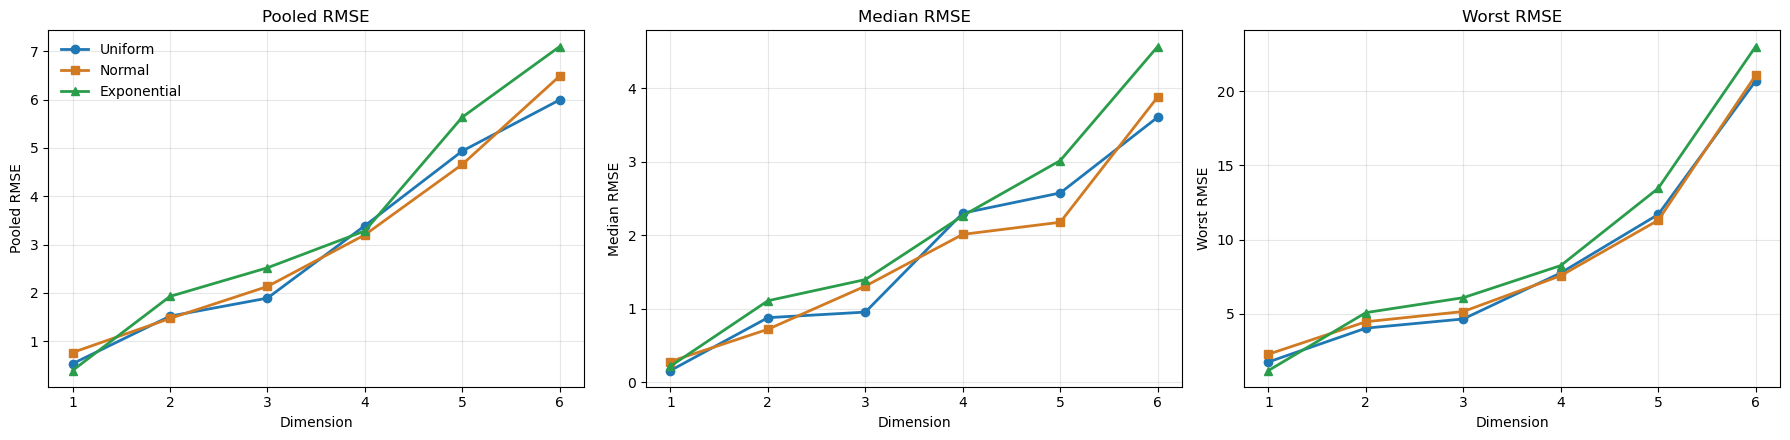

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharex=True)
plot_prior_lines(axes[0], runs_df, "pooled_rmse_log_r10", "Pooled RMSE", "Pooled RMSE")
plot_prior_lines(axes[1], runs_df, "median_rmse_log_r10", "Median RMSE", "Median RMSE")
plot_prior_lines(axes[2], runs_df, "worst_rmse_log_r10", "Worst RMSE", "Worst RMSE")
axes[0].legend(frameon=False)
fig.tight_layout()
plt.show()

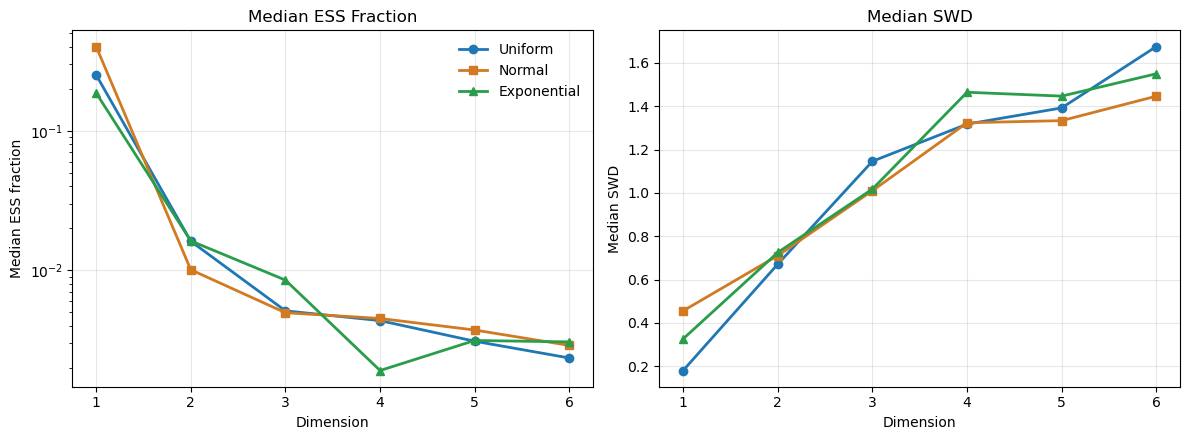

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
plot_prior_lines(axes[0], runs_df, "median_ess_fraction", "Median ESS Fraction", "Median ESS fraction", logy=True)
plot_prior_lines(axes[1], runs_df, "median_swd", "Median SWD", "Median SWD")
axes[0].legend(frameon=False)
fig.tight_layout()
plt.show()

In [7]:
display(build_scaling_observation_markdown(runs_df))

### Scaling interpretation
- The sharpest average pooled-RMSE jump occurs between **1D** and **2D**, where the mean pooled RMSE rises from **0.57** to **1.64**.
- Mean 68% HPD coverage drops below **0.50** at **5D**, which is a strong sign that uncertainty is becoming under-dispersed in the higher-dimensional runs.
- Median effective-sample-size fraction falls below **1%** by **3D**, which matches the worsening reweighting difficulty seen in the SWD plots.
- By **6D**, the sweep combines larger ratio error, lower ESS, and much weaker empirical coverage, so the failure mode is not just a single metric moving in isolation.

## Calibration And Uncertainty

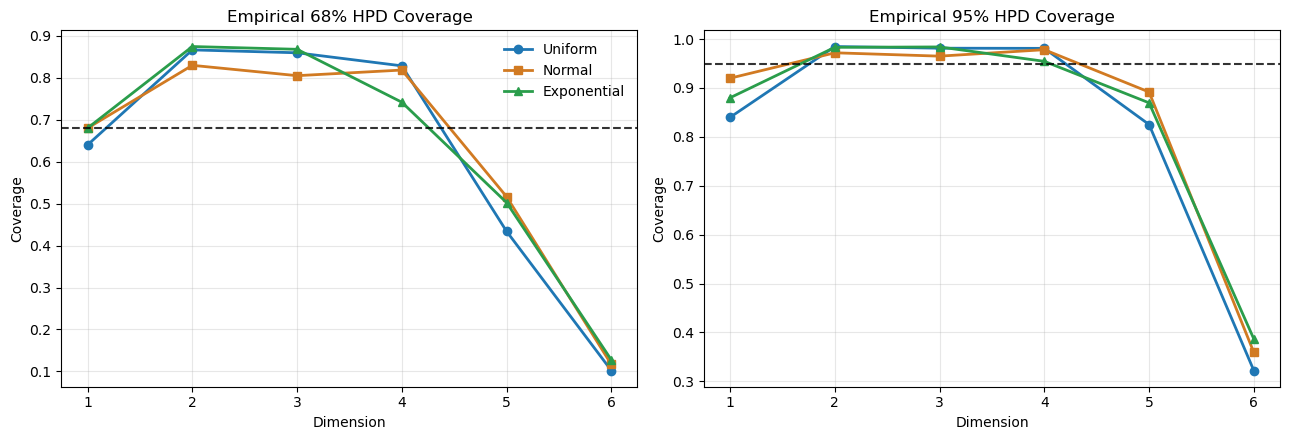

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)
plot_prior_lines(axes[0], runs_df, "coverage_68", "Empirical 68% HPD Coverage", "Coverage")
plot_prior_lines(axes[1], runs_df, "coverage_95", "Empirical 95% HPD Coverage", "Coverage")
axes[0].axhline(0.68, color="black", linestyle="--", linewidth=1.5, alpha=0.8)
axes[1].axhline(0.95, color="black", linestyle="--", linewidth=1.5, alpha=0.8)
axes[0].legend(frameon=False)
fig.tight_layout()
plt.show()

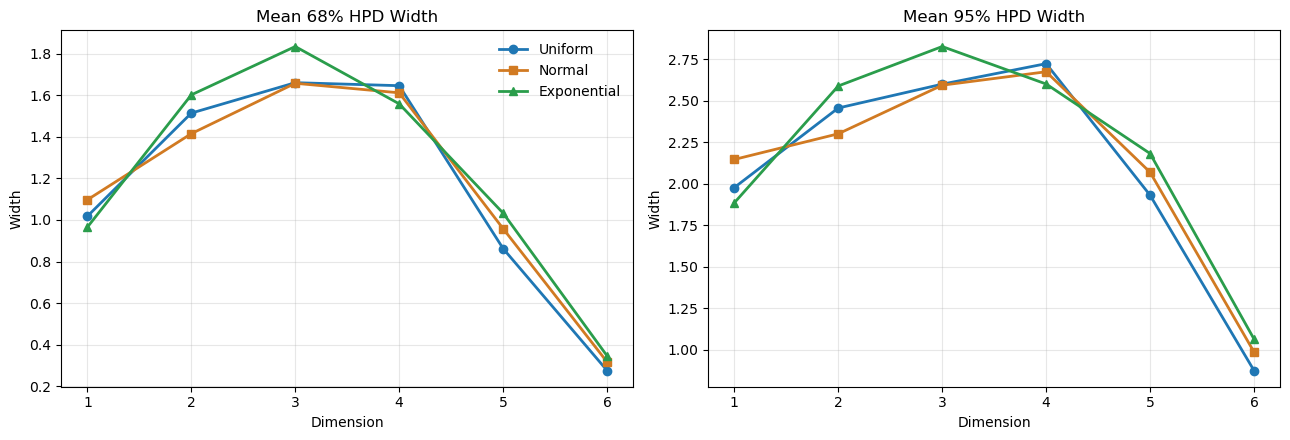

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=True)
plot_prior_lines(axes[0], runs_df, "mean_interval_width_68", "Mean 68% HPD Width", "Width")
plot_prior_lines(axes[1], runs_df, "mean_interval_width_95", "Mean 95% HPD Width", "Width")
axes[0].legend(frameon=False)
fig.tight_layout()
plt.show()

/tmp/ipykernel_1861035/1039282244.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


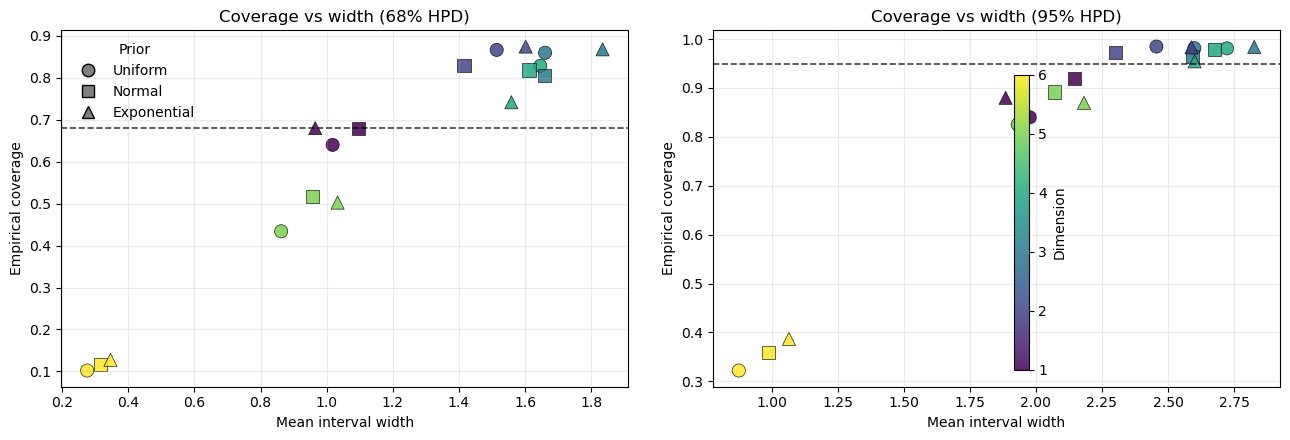

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharex=False, sharey=False)
scatter = None
for ax, level in zip(axes, [68, 95]):
    coverage_col = f"coverage_{level}"
    width_col = f"mean_interval_width_{level}"
    for prior in PRIORS:
        subset = runs_df.loc[runs_df["prior"] == prior]
        if subset.empty:
            continue
        scatter = ax.scatter(
            subset[width_col],
            subset[coverage_col],
            c=subset["dimension"],
            cmap="viridis",
            s=90,
            marker=PRIOR_MARKERS.get(prior, "o"),
            alpha=0.85,
            edgecolor="black",
            linewidth=0.5,
        )
    ax.axhline(level / 100.0, color="black", linestyle="--", linewidth=1.2, alpha=0.75)
    ax.set_title(f"Coverage vs width ({level}% HPD)")
    ax.set_xlabel("Mean interval width")
    ax.set_ylabel("Empirical coverage")
    ax.grid(alpha=0.25)
legend_handles = [
    Line2D(
        [0],
        [0],
        marker=PRIOR_MARKERS[prior],
        color="white",
        label=PRIOR_LABELS[prior],
        markerfacecolor="gray",
        markeredgecolor="black",
        markersize=9,
    )
    for prior in PRIORS
]
axes[0].legend(handles=legend_handles, frameon=False, title="Prior")
if scatter is not None:
    fig.colorbar(scatter, ax=axes.tolist(), shrink=0.85, label="Dimension")
fig.tight_layout()
plt.show()

## Distance-Driven Difficulty

/tmp/ipykernel_1861035/585370360.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


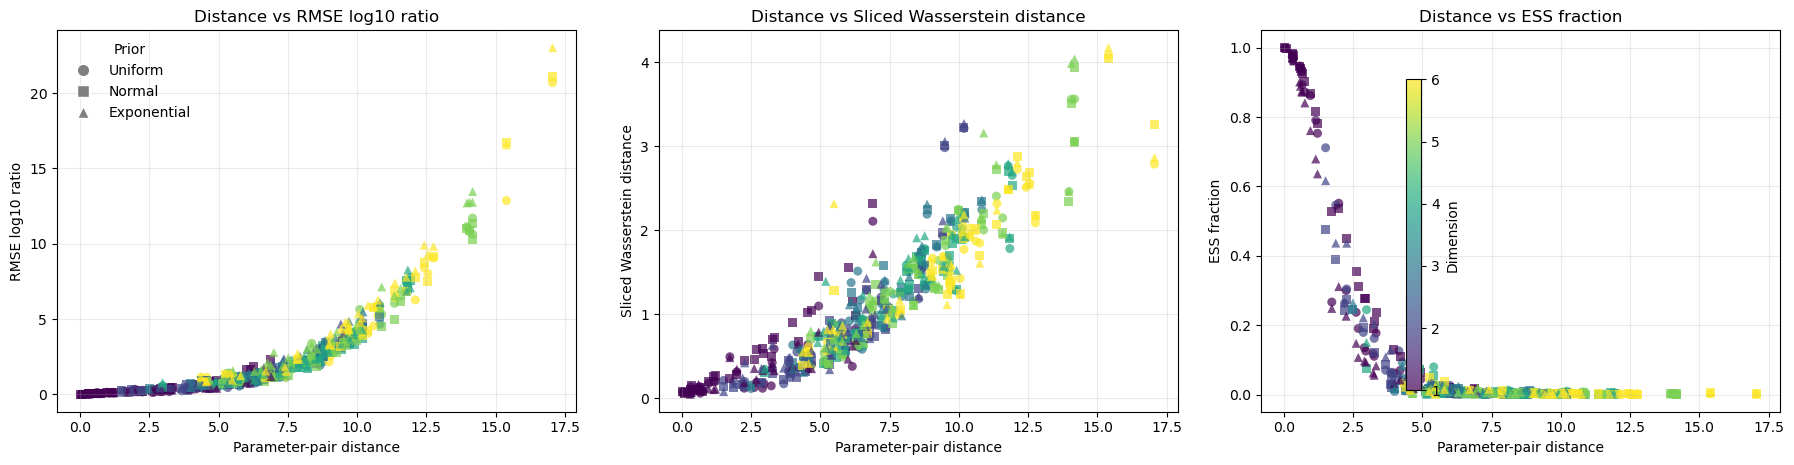

In [11]:
metrics = [
    ("rmse_log_r10", "RMSE log10 ratio"),
    ("swd", "Sliced Wasserstein distance"),
    ("ess_fraction", "ESS fraction"),
]
fig, axes = plt.subplots(1, 3, figsize=(18, 4.75), sharex=True)
scatter = None
for ax, (metric, ylabel) in zip(axes, metrics):
    for prior in PRIORS:
        subset = pairs_df.loc[pairs_df["prior"] == prior]
        if subset.empty:
            continue
        scatter = ax.scatter(
            subset["distance"],
            subset[metric],
            c=subset["dimension"],
            cmap="viridis",
            s=42,
            alpha=0.70,
            marker=PRIOR_MARKERS.get(prior, "o"),
            edgecolor="none",
        )
    ax.set_title(f"Distance vs {ylabel}")
    ax.set_xlabel("Parameter-pair distance")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
legend_handles = [
    Line2D(
        [0],
        [0],
        marker=PRIOR_MARKERS[prior],
        color="white",
        label=PRIOR_LABELS[prior],
        markerfacecolor="gray",
        markersize=9,
    )
    for prior in PRIORS
]
axes[0].legend(handles=legend_handles, frameon=False, title="Prior")
if scatter is not None:
    fig.colorbar(scatter, ax=axes.tolist(), shrink=0.85, label="Dimension")
fig.tight_layout()
plt.show()

In [12]:
display(correlation_summary_df)

,config_id,dimension,prior,stored_spearman_rmse_vs_distance,empirical_spearman_rmse_vs_distance,empirical_pearson_rmse_vs_distance,stored_spearman_swd_vs_distance,empirical_spearman_swd_vs_distance,empirical_pearson_swd_vs_distance,empirical_spearman_ess_fraction_vs_distance
0,config_018,1,exponential,0.992,0.992,0.937,0.904,0.904,0.804,-0.996
1,config_018,1,normal,0.999,0.999,0.933,0.964,0.964,0.929,-0.997
2,config_018,1,uniform,0.963,0.963,0.865,0.851,0.851,0.738,-0.992
3,config_013,2,exponential,0.986,0.986,0.919,0.918,0.918,0.851,-0.956
4,config_013,2,normal,0.973,0.973,0.871,0.945,0.945,0.862,-0.909
5,config_013,2,uniform,0.982,0.982,0.908,0.941,0.941,0.856,-0.947
6,config_012,3,exponential,0.964,0.964,0.931,0.898,0.898,0.925,-0.796
7,config_012,3,normal,0.956,0.956,0.911,0.951,0.951,0.935,-0.786
8,config_012,3,uniform,0.962,0.962,0.912,0.891,0.891,0.910,-0.765
9,config_014,4,exponential,0.988,0.988,0.907,0.899,0.899,0.900,-0.562


## Position-Dependent Behavior

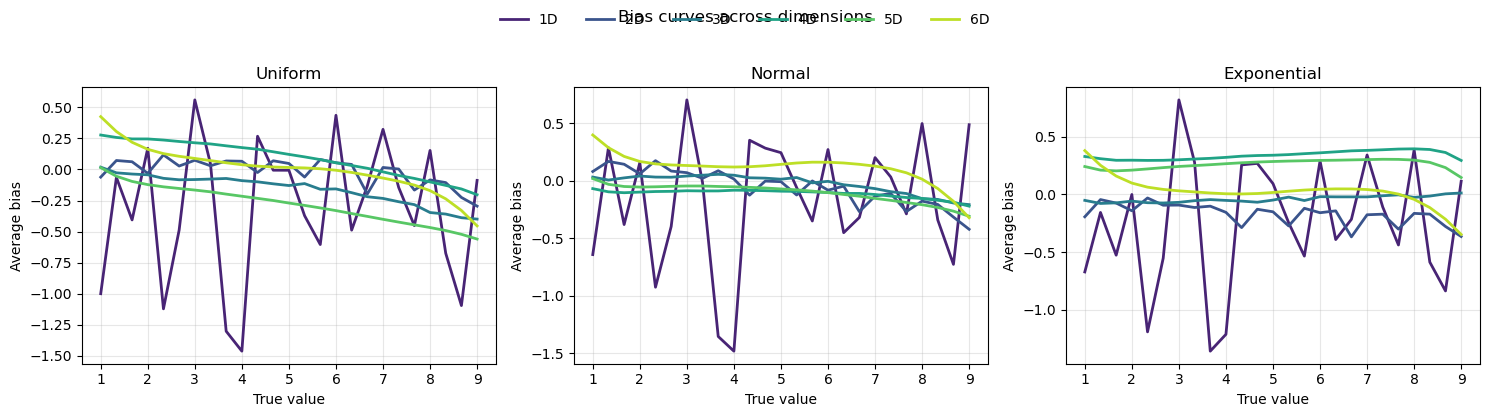

In [13]:
fig = plot_curve_family(curves_df, "avg_bias", "Average bias", "Bias curves across dimensions")
plt.show()

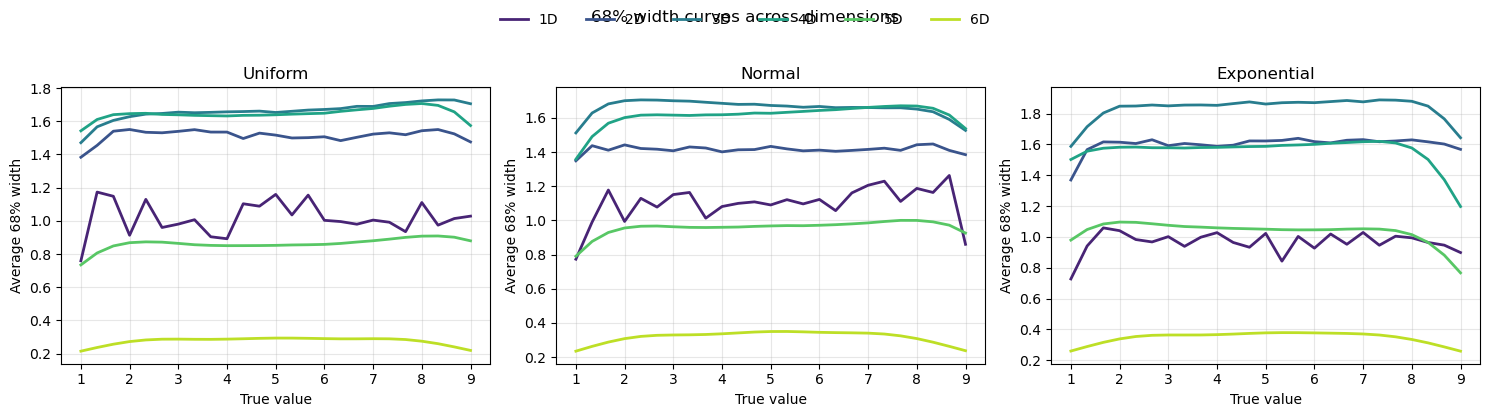

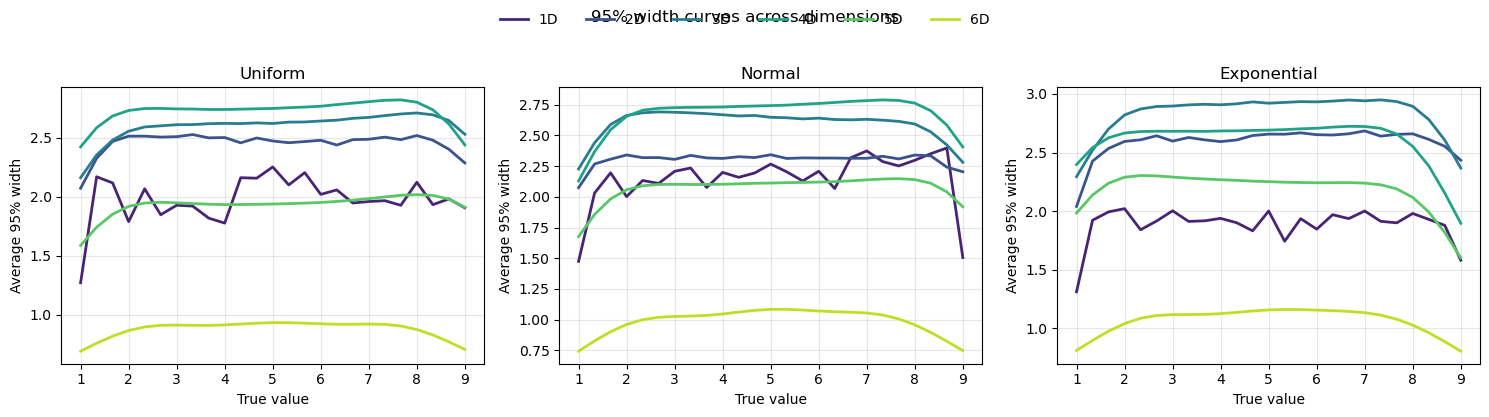

In [14]:
fig = plot_curve_family(curves_df, "avg_width_68", "Average 68% width", "68% width curves across dimensions")
plt.show()

fig = plot_curve_family(curves_df, "avg_width_95", "Average 95% width", "95% width curves across dimensions")
plt.show()

/tmp/ipykernel_1861035/989401218.py:232: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


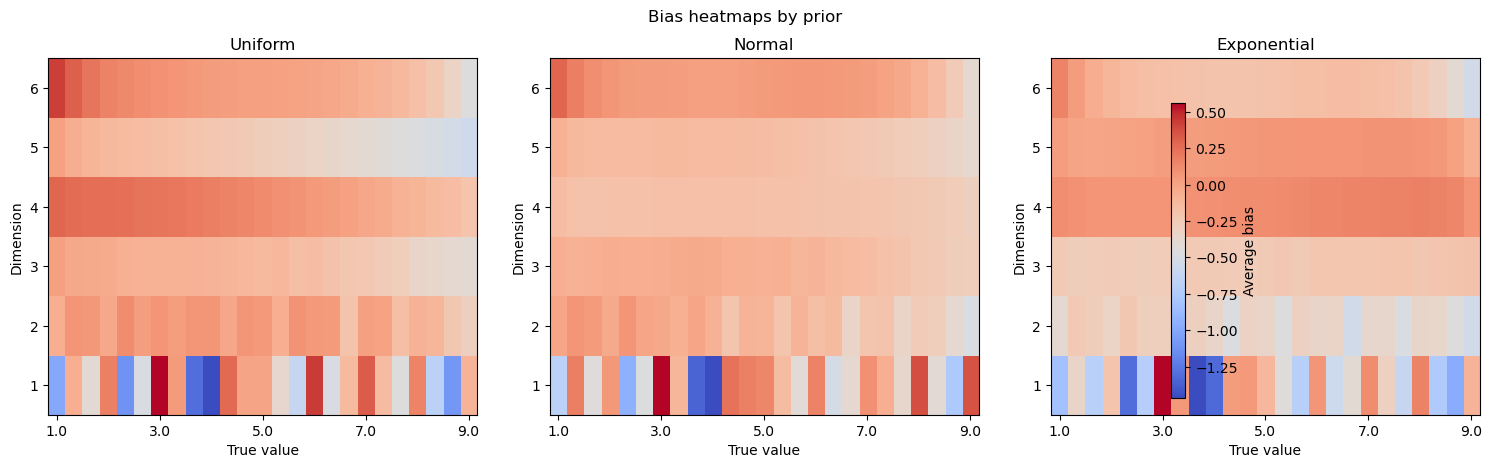

/tmp/ipykernel_1861035/989401218.py:232: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


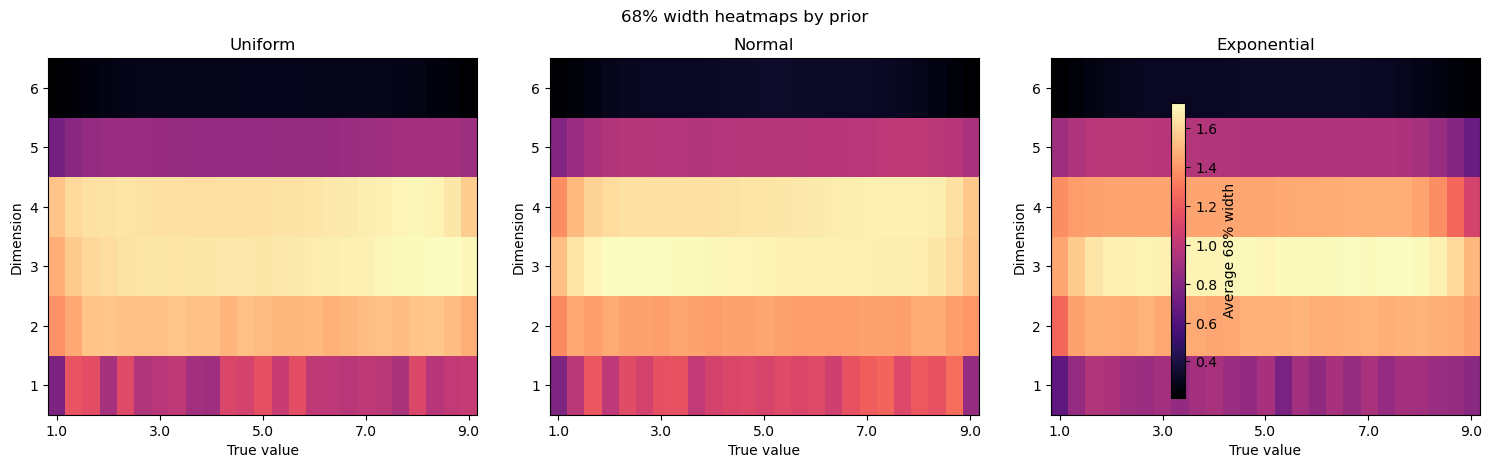

In [15]:
fig = plot_curve_heatmaps(curves_df, "avg_bias", "Average bias", cmap="coolwarm")
fig.suptitle("Bias heatmaps by prior", y=1.03)
plt.show()

fig = plot_curve_heatmaps(curves_df, "avg_width_68", "Average 68% width", cmap="magma")
fig.suptitle("68% width heatmaps by prior", y=1.03)
plt.show()

## Raw Deep Dive (Optional)

In [16]:
if not LOAD_RAW:
    display(
        Markdown(
            f"Set `LOAD_RAW = True` to enable the compact-store deep dive. "
            f"The loader will automatically sample very large arrays down to at most **{RAW_MAX_POINTS_PER_CONFIG:,}** posterior settings per config/prior."
        )
    )
elif raw_metadata_df.empty:
    display(Markdown("Raw loading was enabled, but no raw compact-store artifacts were available for the requested configs."))
else:
    display(raw_metadata_df)

,config_id,dimension,prior,n_total_points,n_loaded_points,sampled
0,config_018,1,exponential,25,25,False
1,config_018,1,normal,25,25,False
2,config_018,1,uniform,25,25,False
3,config_017,6,exponential,244140625,10000,True
4,config_017,6,normal,244140625,10000,True
5,config_017,6,uniform,244140625,10000,True


Deep-dive plots below use the **uniform** prior for readability. Update `PRIORS` or `RAW_CONFIG_IDS` if you want to inspect a different subset.

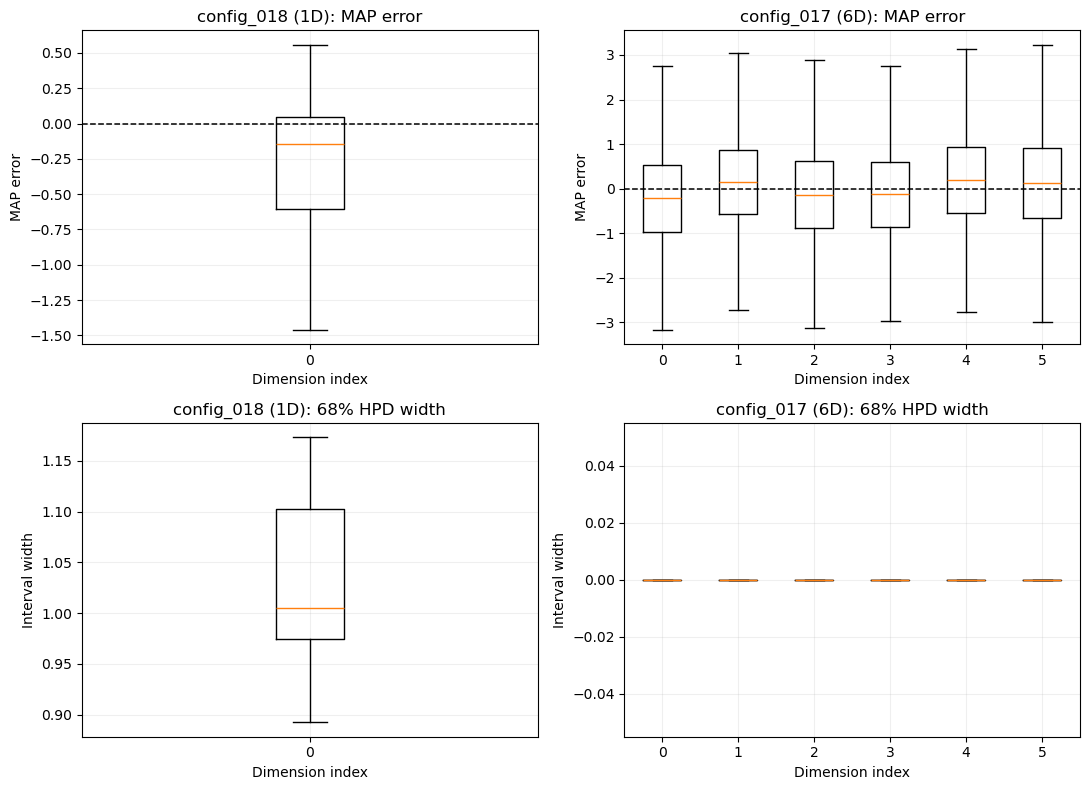

/tmp/ipykernel_1861035/2759279535.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


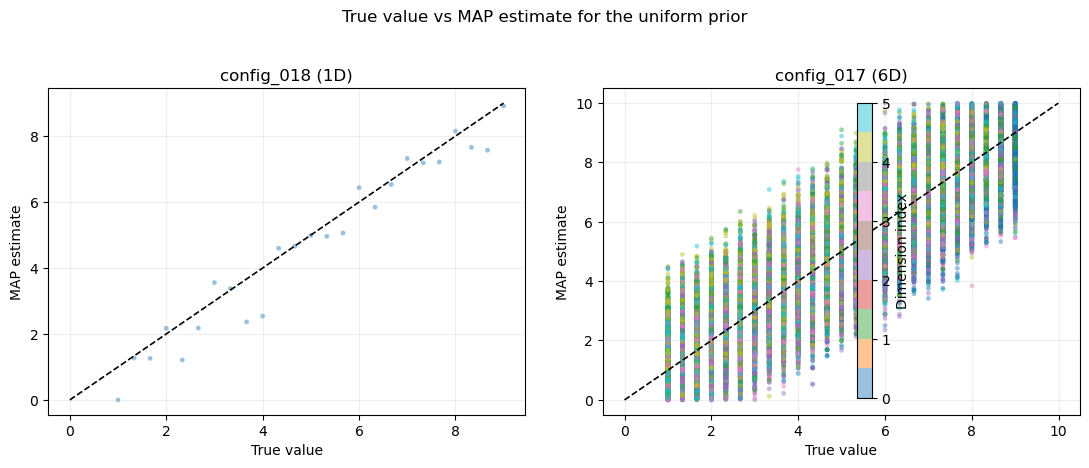

In [17]:
if LOAD_RAW and not raw_metadata_df.empty:
    deep_dive_prior = next((prior for prior in PRIORS if prior in raw_metadata_df["prior"].unique()), None)
    raw_example_configs = (
        raw_metadata_df.loc[raw_metadata_df["prior"] == deep_dive_prior, ["config_id", "dimension"]]
        .drop_duplicates()
        .sort_values("dimension")
        .reset_index(drop=True)
    )
    display(
        Markdown(
            f"Deep-dive plots below use the **{deep_dive_prior}** prior for readability. "
            "Update `PRIORS` or `RAW_CONFIG_IDS` if you want to inspect a different subset."
        )
    )

    map_focus = raw_map_df.loc[raw_map_df["prior"] == deep_dive_prior]
    interval_focus = raw_intervals_df.loc[
        (raw_intervals_df["prior"] == deep_dive_prior)
        & (raw_intervals_df["interval_level"] == "68")
    ]

    ncols = len(raw_example_configs)
    fig, axes = plt.subplots(2, ncols, figsize=(5.5 * ncols, 8), squeeze=False)
    for column, row in raw_example_configs.iterrows():
        config_id = row["config_id"]
        dimension = int(row["dimension"])
        map_subset = map_focus.loc[map_focus["config_id"] == config_id]
        interval_subset = interval_focus.loc[interval_focus["config_id"] == config_id]
        dim_order = sorted(map_subset["dim_index"].unique())

        map_box_data = [map_subset.loc[map_subset["dim_index"] == dim_index, "map_error"].values for dim_index in dim_order]
        width_box_data = [interval_subset.loc[interval_subset["dim_index"] == dim_index, "width"].values for dim_index in dim_order]

        axes[0, column].boxplot(map_box_data, labels=[str(dim_index) for dim_index in dim_order], showfliers=False)
        axes[0, column].axhline(0.0, color="black", linestyle="--", linewidth=1.1)
        axes[0, column].set_title(f"{config_id} ({dimension}D): MAP error")
        axes[0, column].set_xlabel("Dimension index")
        axes[0, column].set_ylabel("MAP error")
        axes[0, column].grid(alpha=0.2)

        axes[1, column].boxplot(width_box_data, labels=[str(dim_index) for dim_index in dim_order], showfliers=False)
        axes[1, column].set_title(f"{config_id} ({dimension}D): 68% HPD width")
        axes[1, column].set_xlabel("Dimension index")
        axes[1, column].set_ylabel("Interval width")
        axes[1, column].grid(alpha=0.2)
    fig.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, ncols, figsize=(5.5 * ncols, 4.5), squeeze=False)
    axes = axes.ravel()
    scatters = []
    for ax, (_, row) in zip(axes, raw_example_configs.iterrows()):
        config_id = row["config_id"]
        dimension = int(row["dimension"])
        map_subset = map_focus.loc[map_focus["config_id"] == config_id]
        scatter = ax.scatter(
            map_subset["true_value"],
            map_subset["map_estimate"],
            c=map_subset["dim_index"],
            cmap="tab10",
            s=12,
            alpha=0.45,
            edgecolor="none",
        )
        scatters.append(scatter)
        low = min(map_subset["true_value"].min(), map_subset["map_estimate"].min())
        high = max(map_subset["true_value"].max(), map_subset["map_estimate"].max())
        ax.plot([low, high], [low, high], linestyle="--", color="black", linewidth=1.2)
        ax.set_title(f"{config_id} ({dimension}D)")
        ax.set_xlabel("True value")
        ax.set_ylabel("MAP estimate")
        ax.grid(alpha=0.2)
    fig.colorbar(scatters[-1], ax=axes.tolist(), shrink=0.85, label="Dimension index")
    fig.suptitle(f"True value vs MAP estimate for the {deep_dive_prior} prior", y=1.03)
    fig.tight_layout()
    plt.show()